In [1]:
import numpy as np
from numpy import cos, sin
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.patches import Circle
mu = 1.2150584270572e-2

Select the file to get data from and decided whether to export the IVP solution. As with all analysis tools in this project, the .npz file provided must have the state and time at a minimum. This solver is working in the 3D version of the 3 body problem, not the 2D version.

In [2]:
# Select the file to get data from and the name of the exported file
file_name = "free_return_1-1"
path_modifiers = ""
reference_name = path_modifiers + file_name + ".npz"
export_name = file_name + "_ivp"

# Set to 1 to export results as a .npz
export = 1

In [3]:
# Define the equations of motion and set up the first-order system of differential equations

def three_body(t, vec):
    x, y, z, vx, vy, vz = vec

    # Equations of Motion
    r1 = np.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

    ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
    ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx
    az = -(1 - mu)*z/r1**3 - mu*z/r2**3

    # System of first-order ODEs
    xdot = vx
    ydot = vy
    zdot = vz
    vxdot = ax
    vydot = ay
    vzdot = az

    return [xdot, ydot, zdot, vxdot, vydot, vzdot]

In [4]:
# yapss_sol = np.load(reference_name)
# state = yapss_sol["state"]
# time = yapss_sol["time"]

scale = 3.1
vec0 = test = np.array([0.8800164192870448, -0.001061053325458559, 0, -0.060075855942239687*scale, -0.24389825354382633*scale, 0])
t_span = [6.1750136375952085, 7.073544359940579]

rtol = 1e-14
atol = 1e-24

ivp_sol = solve_ivp(three_body, t_span, vec0, t_eval=None, method='DOP853', rtol=rtol, atol=atol)

c:\Users\Connor Emmons\MIT\Research Projects\Thesis\Code\.venv\Lib\site-packages\scipy\integrate\_ivp\rk.py:505: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  super().__init__(fun, t0, y0, t_bound, max_step, rtol, atol,


In [5]:
if export == 1:
    np.savez(
    export_name,
    state = ivp_sol.y,
    time = ivp_sol.t,
)
    
x, y, z, vx, vy, vz = ivp_sol.y

In [6]:
file_name = "3dorbit"
path_modifier = "../Standard_Cycler_Generation/"
reference_name = path_modifier + file_name + ".npz"
orbit = np.load(reference_name)

xr, yr, zr, vxr, vyr, vzr = orbit["state"]
t = orbit["time"]

idx_mid = len(t)//2

t[540]
vyr[540]

np.float64(-0.24389825354419103)

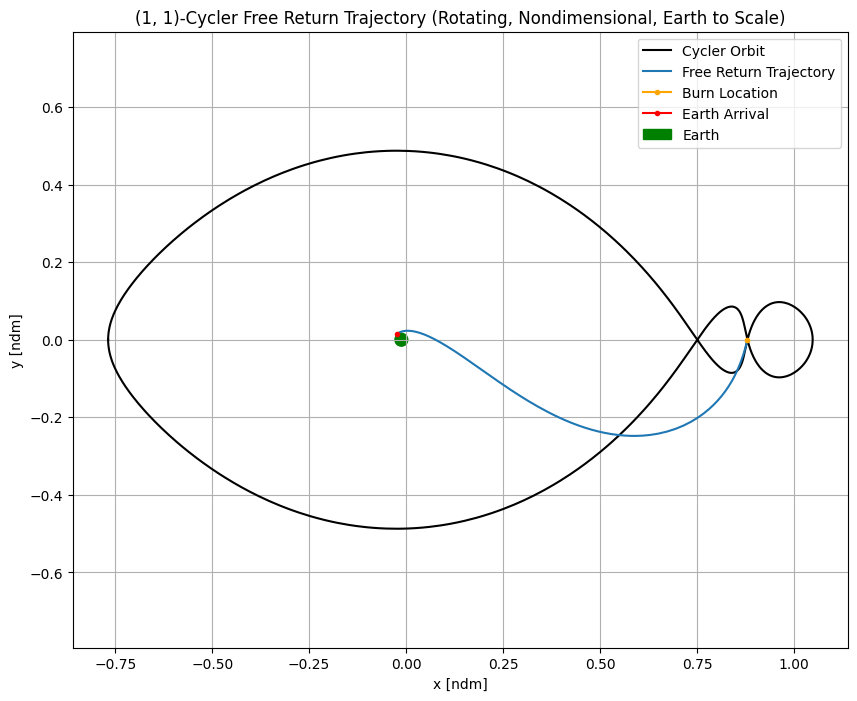

In [7]:
fig = plt.figure(figsize=(10,8))
fig.tight_layout()

ax1 = fig.add_subplot(1, 1, 1)
ax1.plot(xr, yr, color='black', label='Cycler Orbit')
ax1.plot(x, y, label='Free Return Trajectory')
ax1.plot(xr[540], yr[540], marker='.', color='orange', label='Burn Location')
ax1.plot(x[-1], y[-1], marker='.', color='red', label='Earth Arrival')
earth = Circle((-mu, 0), 6378.137/384400, label='Earth', color='Green')
ax1.add_patch(earth)
ax1.axis("equal")
ax1.set_xlabel("x [ndm]")
ax1.set_ylabel("y [ndm]")
ax1.set_title("(1, 1)-Cycler Free Return Trajectory (Rotating, Nondimensional, Earth to Scale)")
ax1.legend()
ax1.grid(True)

In [8]:
mu = 1.2150584270572e-2

def t_to_day(t):
    return t*27.321661/2/np.pi

def day_to_t(t):
    return t*2*np.pi/27.321661

def x_to_dist(x):
    return x*384400

def unit_convert(x):
    x_new = np.zeros(np.shape(x))
    for i in range(np.shape(x)[1]):
        x_new[0:3,i] = x_to_dist(x[0:3,i])
        x_new[3:6,i] = day_to_t(x_to_dist(x[3:6,i]))/86400
    return x_new

def rotate_state(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            vx*cos(theta) - vy*sin(theta),
            vx*sin(theta) + vy*cos(theta),
            vz])
    return state_inertial

def rotate_state2(state, time_ang):
    state_inertial = np.zeros(np.shape(state))
    for i in range(np.shape(state)[1]):
        x, y, z, vx, vy, vz = state[:,i]
        theta = time_ang[i]
        state_inertial[:,i] = np.array([
            x*cos(theta) - y*sin(theta),
            x*sin(theta) + y*cos(theta),
            z,
            (vx - y)*cos(theta) - (vy + x)*sin(theta),
            (vx - y)*sin(theta) + (vy + x)*cos(theta),
            vz])
    return unit_convert(state_inertial)

In [9]:
delta_v = rotate_state2(np.array([0.8800164192870448, -0.001061053325458559, 0, -0.060075855942239687, -0.24389825354382633, 0]).reshape(6, 1), np.array([6.1750136375952085])) - rotate_state2(np.array([0.8800164192870448, -0.001061053325458559, 0, -0.060075855942239687*scale, -0.24389825354382633*scale, 0]).reshape(6, 1), np.array([6.1750136375952085]))
np.linalg.norm(delta_v)

np.float64(0.5397103905228754)

In [10]:
t_to_day(ivp_sol.t[-1] - ivp_sol.t[0])

np.float64(3.907150687717837)